# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load Dataset
df = pd.read_csv("Air_Quality.csv")

In [3]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB
None


In [4]:
print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
           Unique ID  Indicator ID   Geo Join ID    Data Value  Message
count   18862.000000  18862.000000  1.886200e+04  18862.000000      0.0
mean   452004.167533    431.817888  5.983262e+05     21.051580      NaN
std    262910.731230    113.946565  7.819721e+06     23.564920      NaN
min    130355.000000    365.000000  1.000000e+00      0.000000      NaN
25%    176073.250000    365.000000  2.020000e+02      8.742004      NaN
50%    412490.500000    375.000000  3.030000e+02     14.790000      NaN
75%    669588.750000    386.000000  4.040000e+02     26.267500      NaN
max    878254.000000    661.000000  1.051061e+08    424.700000      NaN


# Data Preprocessing

In [5]:
# Remove Message Column
processed_df = df.drop(columns=["Message"], errors="ignore")

# Convert Date Column
processed_df["Start_Date"] = pd.to_datetime(processed_df["Start_Date"])

# Extract Temporal Feature
processed_df["Year"] = processed_df["Start_Date"].dt.year

# Encode Categorical Columns
label_encoder = LabelEncoder()

categorical_columns = [
    "Name",
    "Measure",
    "Measure Info",
    "Geo Type Name",
    "Geo Place Name",
    "Time Period"
]

for col in categorical_columns:
    processed_df[col] = label_encoder.fit_transform(processed_df[col])

# Define Features and Target
X = processed_df.drop(columns=["Data Value", "Start_Date"])
y = processed_df["Data Value"]

# Display Processed Data
print("\nProcessed Dataset Shape:", processed_df.shape)
print("\nProcessed Data:")
print(processed_df.head())

print("\nFeature Columns:")
print(X.columns)

print("\nTarget Variable:")
print("Data Value")


Processed Dataset Shape: (18862, 12)

Processed Data:
   Unique ID  Indicator ID  Name  Measure  Measure Info  Geo Type Name  \
0     336867           375    13        5             6              1   
1     336741           375    13        5             6              1   
2     550157           375    13        5             6              1   
3     412802           375    13        5             6              1   
4     412803           375    13        5             6              1   

   Geo Join ID  Geo Place Name  Time Period Start_Date  Data Value  Year  
0          407              37           48 2014-12-01       23.97  2014  
1          107             106           48 2014-12-01       27.42  2014  
2          414              81           20 2017-01-01       12.55  2017  
3          407              37           49 2015-12-01       22.63  2015  
4          407              37           34 2016-06-01       14.00  2016  

Feature Columns:
Index(['Unique ID', 'Indicator I

# EDA

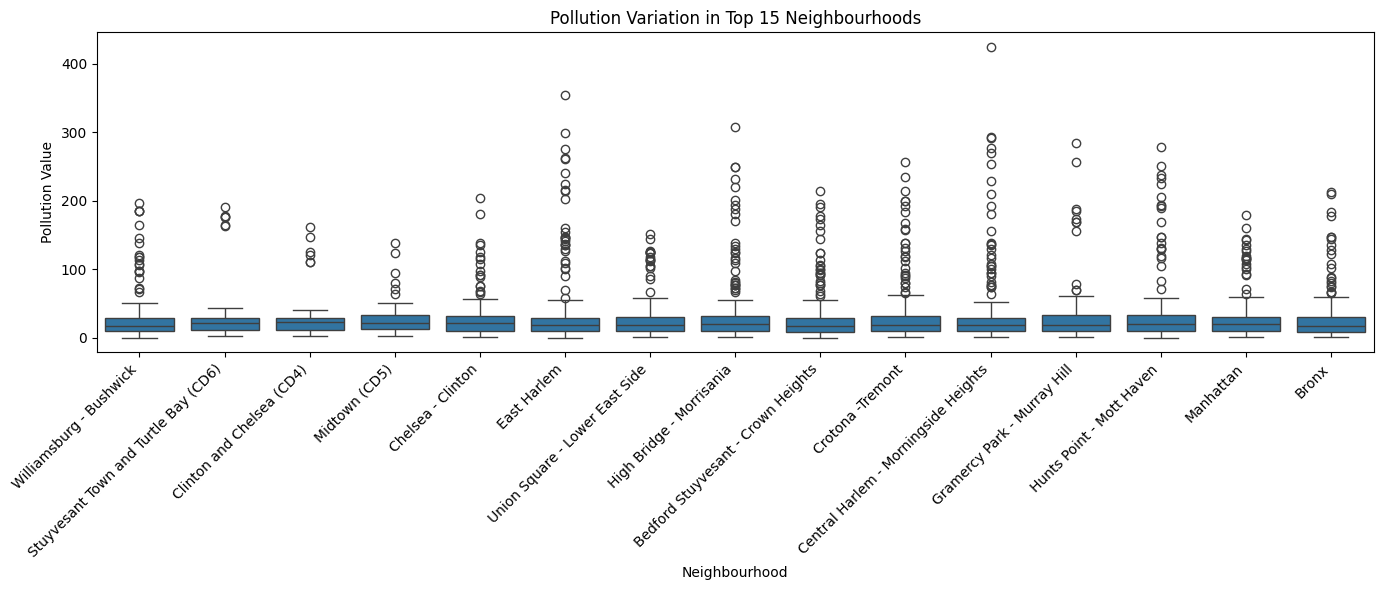

In [6]:
# Top 15 polluted neighbourhoods
top_places = df.groupby("Geo Place Name")["Data Value"].mean().sort_values(ascending=False).head(15).index
df_top = df[df["Geo Place Name"].isin(top_places)]
plt.figure(figsize=(14,6))
sns.boxplot(x="Geo Place Name", y="Data Value", data=df_top)
plt.title("Pollution Variation in Top 15 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Pollution Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

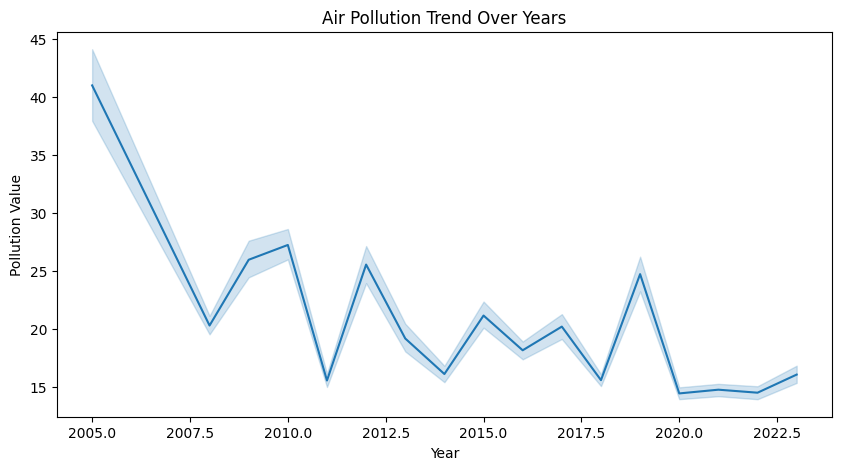

In [7]:
# Pollution Over Time
plt.figure(figsize=(10,5))
sns.lineplot(x="Year", y="Data Value", data=processed_df)
plt.title("Air Pollution Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Pollution Value")
plt.show()

/tmp/ipykernel_35542/3196642358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Indicator ID", y="Data Value", data=processed_df, palette="coolwarm")


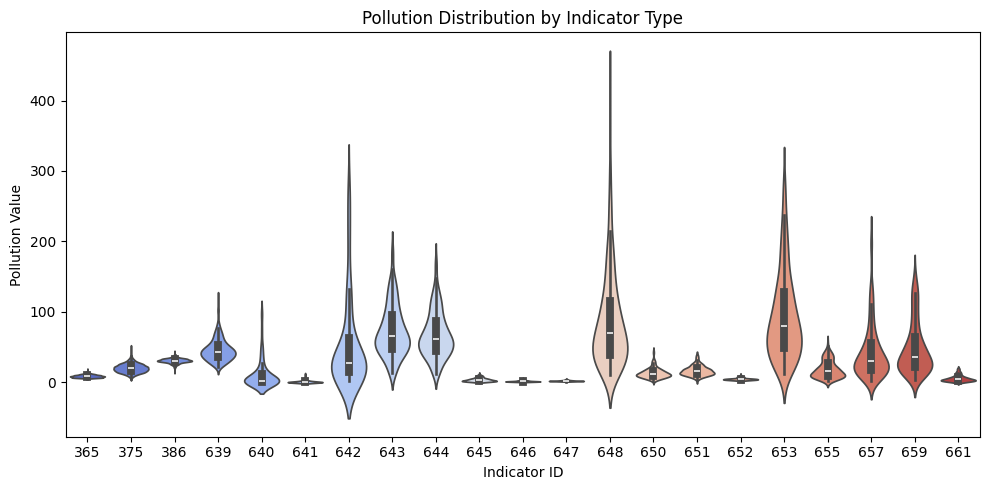

In [8]:
# Pollution by Indicator
plt.figure(figsize=(10,5))
sns.violinplot(x="Indicator ID", y="Data Value", data=processed_df, palette="coolwarm")
plt.title("Pollution Distribution by Indicator Type")
plt.xlabel("Indicator ID")
plt.ylabel("Pollution Value")
plt.tight_layout()
plt.show()

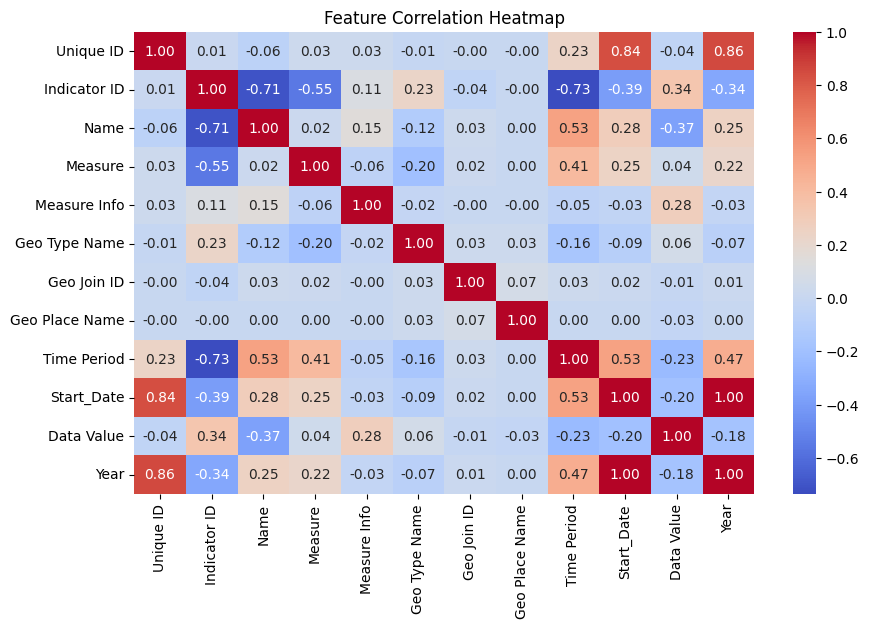

In [9]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
corr = processed_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

/tmp/ipykernel_35542/1383871339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Geo Type Name", y="Data Value", data=df, palette="viridis", jitter=True)


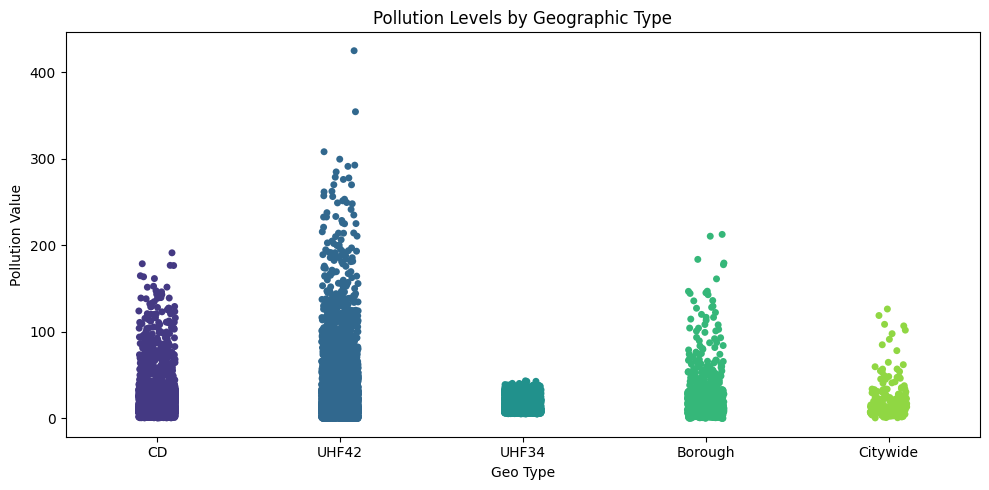

In [10]:
# Pollution by Geo Type
plt.figure(figsize=(10,5))
sns.stripplot(x="Geo Type Name", y="Data Value", data=df, palette="viridis", jitter=True)
plt.title("Pollution Levels by Geographic Type")
plt.xlabel("Geo Type")
plt.ylabel("Pollution Value")
plt.tight_layout()
plt.show()

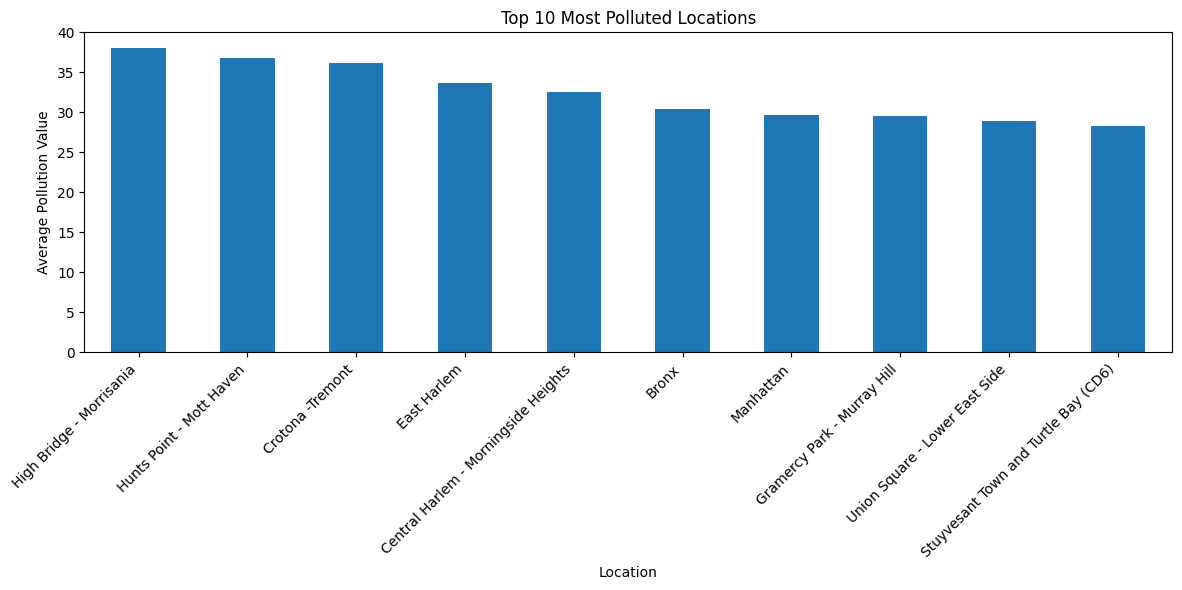

In [11]:
# Top Polluted Locations
top_locations = df.groupby("Geo Place Name")["Data Value"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_locations.plot(kind="bar")
plt.title("Top 10 Most Polluted Locations")
plt.xlabel("Location")
plt.ylabel("Average Pollution Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Engineering

In [12]:
feature_df = processed_df.copy()

# Spatial Features
feature_df["Geo_Area_Code"] = feature_df["Geo Join ID"]

feature_df["Geo_Type_Encoded"] = LabelEncoder().fit_transform(feature_df["Geo Type Name"])

feature_df["Place_Encoded"] = LabelEncoder().fit_transform(feature_df["Geo Place Name"])


# Temporal Features
feature_df["Year"] = pd.to_datetime(feature_df["Start_Date"]).dt.year
feature_df["Month"] = pd.to_datetime(feature_df["Start_Date"]).dt.month


# Seasonal Indicator
def extract_season(period):
    period = str(period).lower()
    if "winter" in period:
        return "Winter"
    elif "summer" in period:
        return "Summer"
    elif "annual" in period:
        return "Annual"
    else:
        return "Other"

feature_df["Season"] = feature_df["Time Period"].apply(extract_season)

feature_df["Season"] = LabelEncoder().fit_transform(feature_df["Season"])


# Indicator Feature
feature_df["Pollutant_Type"] = LabelEncoder().fit_transform(feature_df["Name"])


# Final Feature Set
features = [
    "Indicator ID",
    "Geo_Area_Code",
    "Geo_Type_Encoded",
    "Place_Encoded",
    "Year",
    "Month",
    "Season",
    "Pollutant_Type"
]

X = feature_df[features]
y = feature_df["Data Value"]


# Display Engineered Features
print("Feature Engineered Dataset Shape:", feature_df.shape)
print("\nSelected Features:")
print(X.head())

Feature Engineered Dataset Shape: (18862, 18)

Selected Features:
   Indicator ID  Geo_Area_Code  Geo_Type_Encoded  Place_Encoded  Year  Month  \
0           375            407                 1             37  2014     12   
1           375            107                 1            106  2014     12   
2           375            414                 1             81  2017      1   
3           375            407                 1             37  2015     12   
4           375            407                 1             37  2016      6   

   Season  Pollutant_Type  
0       0              13  
1       0              13  
2       0              13  
3       0              13  
4       0              13  


# ML Models

In [13]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

lr_predictions = best_lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

cv_scores = cross_val_score(best_lr, X_train, y_train, cv=5, scoring="r2")

print("Linear Regression Performance")
print("Best Parameters:", lr_grid.best_params_)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)
print("Cross Validation R2 Mean:", cv_scores.mean())

Linear Regression Performance
Best Parameters: {'fit_intercept': True, 'positive': False}
RMSE: 23.22881434262171
MAE: 13.609646663207073
R2: 0.15843988814218235
Cross Validation R2 Mean: 0.15133406326332582


In [15]:
# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

Random Forest Performance
RMSE: 5.574246375607011
MAE: 1.8531001493728263
R2: 0.9515377719208067



Random Forest Feature Importance:
            Feature  Importance
7    Pollutant_Type    0.358801
0      Indicator ID    0.249954
1     Geo_Area_Code    0.223944
3     Place_Encoded    0.097491
4              Year    0.045384
2  Geo_Type_Encoded    0.013847
5             Month    0.010580
6            Season    0.000000


/tmp/ipykernel_35542/1649306318.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


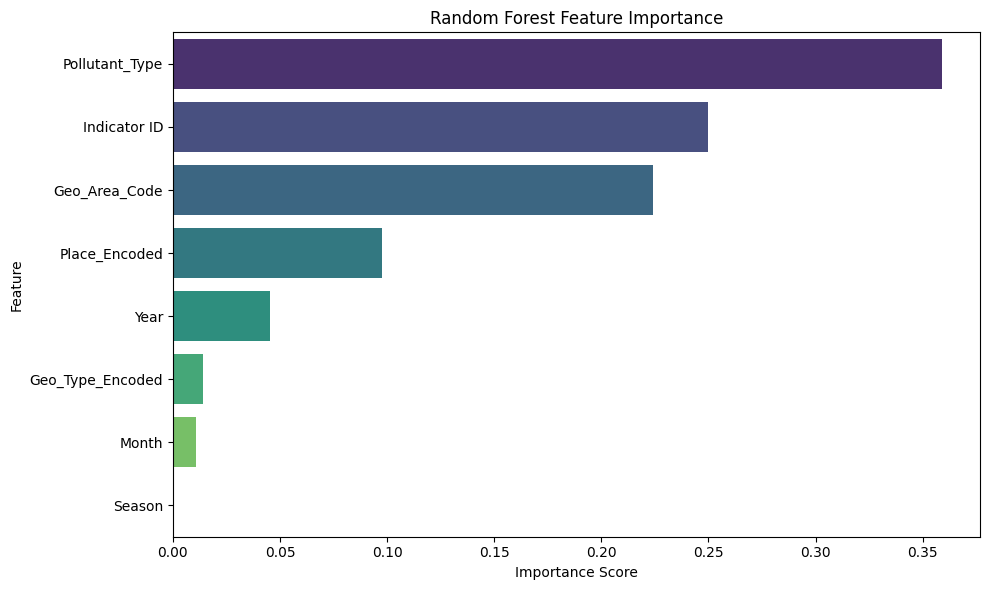

In [16]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    palette="viridis"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [17]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Performance")
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)
print("R2:", gb_r2)

Gradient Boosting Performance
RMSE: 13.28964392229403
MAE: 4.991186098558054
R2: 0.7245405053112963


In [18]:
# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Performance")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R2:", xgb_r2)

XGBoost Performance
RMSE: 6.88665406057557
MAE: 2.7672062952234637
R2: 0.926031367132899



Prediction Error by Geographic Unit:
Place_Encoded
17     6.990962
102    6.730414
28     6.512818
45     6.390359
42     6.320969
63     5.993533
18     5.868631
61     5.845998
47     5.444857
111    5.093697
Name: Error, dtype: float64


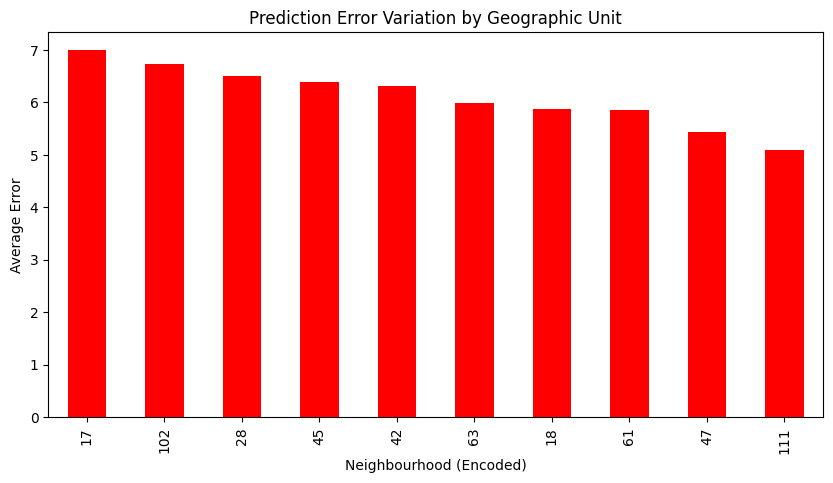

In [19]:
# Spatial Prediction Error Analysis
error_df = X_test.copy()
error_df["Actual"] = y_test
error_df["Predicted"] = xgb_predictions
error_df["Error"] = abs(error_df["Actual"] - error_df["Predicted"])

geo_error = error_df.groupby("Place_Encoded")["Error"].mean().sort_values(ascending=False)

print("\nPrediction Error by Geographic Unit:")
print(geo_error.head(10))

plt.figure(figsize=(10,5))
geo_error.head(10).plot(kind="bar", color="red")
plt.title("Prediction Error Variation by Geographic Unit")
plt.xlabel("Neighbourhood (Encoded)")
plt.ylabel("Average Error")
plt.show()

In [20]:
# Model Comparison Table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse, xgb_rmse],
    "MAE": [lr_mae, rf_mae, gb_mae, xgb_mae],
    "R2": [lr_r2, rf_r2, gb_r2, xgb_r2]
})

print(results)

               Model       RMSE        MAE        R2
0  Linear Regression  23.228814  13.609647  0.158440
1      Random Forest   5.574246   1.853100  0.951538
2  Gradient Boosting  13.289644   4.991186  0.724541
3            XGBoost   6.886654   2.767206  0.926031


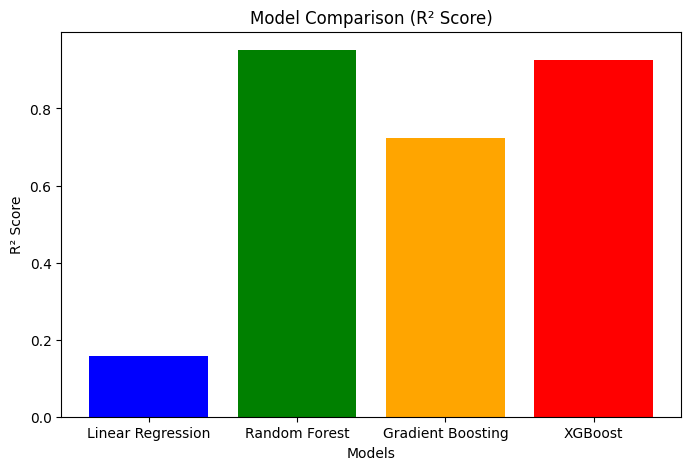

In [21]:
# Model Comparison Plot
models = ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"]
r2_scores = [lr_r2, rf_r2, gb_r2, xgb_r2]

colors = ["blue", "green", "orange", "red"]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores, color=colors)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xlabel("Models")

plt.show()